# Trabajo Práctico Integrador — Hito 1: Análisis Exploratorio de Datos (EDA)

**Materia:** Fundamentos de Data Science — Universidad de Palermo

**Integrantes:**
| Nombre | Legajo |
|---|---|
| Crismary Castellanos | 0121105 |
| _Integrante 2 | |
| _Integrante 3 | |
| _Integrante 4 | |
| _Integrante 5 | |

**Dataset elegido:** Aerolínea (clasificación)

## 1. Descripción del problema





## 2. Importación de librerías y carga de datos



In [1]:
# Librerías estándar para el EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("data/Invistico_Airline.csv")

df.head()


,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


## 3. Descripción general del dataset


## 4. Análisis de valores nulos


Primero revisamos cuántos valores nulos hay en cada columna y qué porcentaje representan sobre el total de registros. Esto nos permite evaluar si hace falta completar datos o eliminar filas antes del modelado.

In [2]:
# Cantidad y porcentaje de valores nulos por variable
resumen_nulos = pd.DataFrame({
    "valores nulos": df.isnull().sum(),
    "% nulos": (df.isnull().mean() * 100).round(2),
})

resumen_nulos.sort_values("valores nulos", ascending=False)

,valores nulos,% nulos
Arrival Delay in Minutes,393,0.3
Inflight entertainment,0,0.0
Departure Delay in Minutes,0,0.0
Online boarding,0,0.0
Cleanliness,0,0.0
Checkin service,0,0.0
Baggage handling,0,0.0
Leg room service,0,0.0
On-board service,0,0.0
Ease of Online booking,0,0.0


Total de filas: 129880
Filas con al menos un nulo: 393
Porcentaje de filas con nulos: 0.3 %


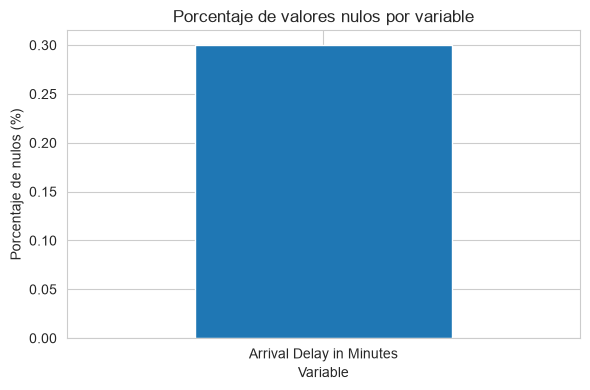

In [3]:
# Filas que tienen al menos un valor nulo
filas_con_nulos = df.isnull().any(axis=1).sum()

print("Total de filas:", len(df))
print("Filas con al menos un nulo:", filas_con_nulos)
print("Porcentaje de filas con nulos:", round(100 * filas_con_nulos / len(df), 2), "%")

# Gráfico de las columnas que presentan valores nulos
columnas_con_nulos = resumen_nulos[resumen_nulos["valores nulos"] > 0]

if not columnas_con_nulos.empty:
    columnas_con_nulos["% nulos"].plot(
        kind="bar", figsize=(6, 4), title="Porcentaje de valores nulos por variable"
    )
    plt.xlabel("Variable")
    plt.ylabel("Porcentaje de nulos (%)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron valores nulos en el dataset.")

In [4]:
# Imputación con la mediana en una copia, conservando df para el EDA
mediana_llegada = df["Arrival Delay in Minutes"].median()
df_imputado = df.copy()
df_imputado["Arrival Delay in Minutes"] = df_imputado["Arrival Delay in Minutes"].fillna(mediana_llegada)

print("Mediana utilizada:", mediana_llegada, "minutos")
print("Nulos antes de imputar:", df["Arrival Delay in Minutes"].isnull().sum())
print("Nulos después de imputar:", df_imputado["Arrival Delay in Minutes"].isnull().sum())

Mediana utilizada: 0.0 minutos
Nulos antes de imputar: 393
Nulos después de imputar: 0


**Interpretación**

Encontramos 393 valores nulos en `Arrival Delay in Minutes`, lo que representa aproximadamente el 0,30% de las 129.880 filas del dataset. El resto de las columnas no presenta valores faltantes, incluida `satisfaction`, que es nuestro target.

Como la proporción es pequeña, no consideramos necesario eliminar la variable. En esta etapa mantenemos los nulos y realizamos las estadísticas y los gráficos de esa columna sobre los valores disponibles. Esto permite observar la distribución original sin agregar demoras que no fueron registradas. El porcentaje bajo, por sí solo, no permite asegurar que los faltantes sean aleatorios.

Como tratamiento, completamos los nulos con la **mediana** en una copia llamada `df_imputado`, ya que las demoras presentan valores extremos que pueden elevar el promedio. La mediana observada es de 0 minutos y, después de la imputación, no quedan nulos en esa copia. Esta decisión asigna a los registros sin demora de llegada informada un valor de 0; es una aproximación, no una confirmación de que esos vuelos llegaron sin retraso. El resto del EDA utiliza `df` para conservar las distribuciones observadas.

Esta imputación es una demostración para la etapa exploratoria. Para el modelado se deberá partir de los datos originales, separar entrenamiento y validación, y calcular la mediana únicamente con el conjunto de entrenamiento. Luego se utilizará ese mismo valor para completar los datos de validación o prueba, evitando incorporar información de esos conjuntos al entrenamiento.

Los valores 0 de las calificaciones se conservan como aparecen en el dataset: no son nulos detectados por pandas. Antes de darles otro tratamiento, habría que confirmar su significado en la documentación de la encuesta.

## 5. Distribución de las variables


Para analizar las distribuciones separamos las variables en tres grupos, siguiendo el mismo criterio que usamos en las secciones siguientes:

- **Variables continuas / de rango amplio:** edad, distancia de vuelo y demoras. Usamos estadísticas descriptivas e histogramas para observar dónde se concentran los valores y si hay asimetría. La edad está registrada en años enteros, pero la incluimos en este grupo por su rango.
- **Variables de calificación:** son respuestas en una escala acotada. Usamos gráficos de barras para contar cuántas veces aparece cada puntaje.
- **Variables categóricas:** usamos frecuencias, porcentajes y gráficos de barras. Incluimos `satisfaction` para revisar el balance del target.

In [5]:
# Grupos de variables para analizar sus distribuciones
num_cols = df.select_dtypes(include="number").columns.tolist()
continuas = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
calificaciones = [c for c in num_cols if c not in continuas]
categoricas = ["Gender", "Customer Type", "Type of Travel", "Class"]
target = "satisfaction"

# Resumen estadístico de las variables de rango amplio
# describe() calcula las estadísticas sobre los valores no nulos
df[continuas].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,129880.0,39.43,15.12,7.0,27.0,40.0,51.0,85.0
Flight Distance,129880.0,1981.41,1027.12,50.0,1359.0,1925.0,2544.0,6951.0
Departure Delay in Minutes,129880.0,14.71,38.07,0.0,0.0,0.0,12.0,1592.0
Arrival Delay in Minutes,129487.0,15.09,38.47,0.0,0.0,0.0,13.0,1584.0


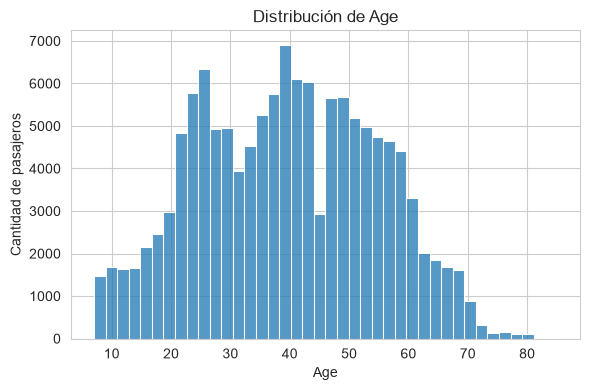

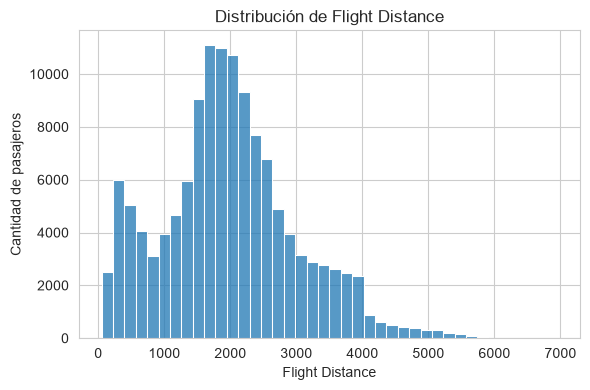

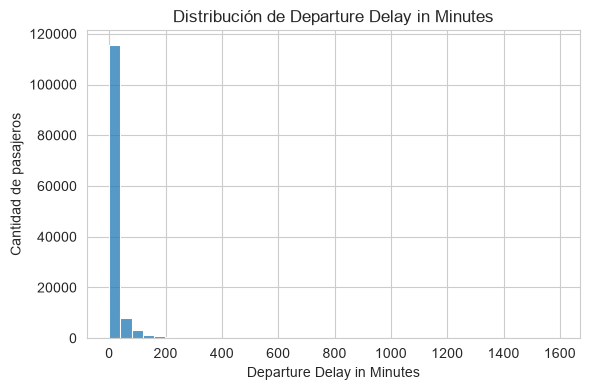

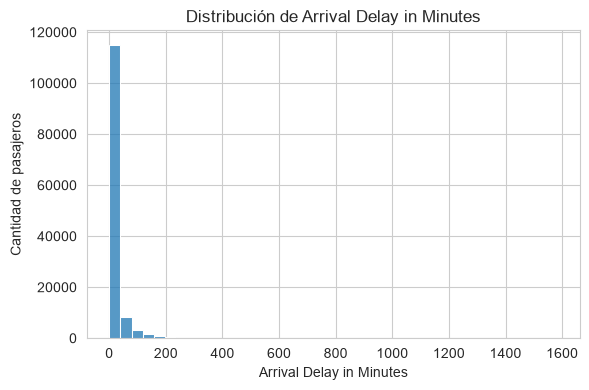

In [6]:
# Histogramas de las variables continuas
for col in continuas:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, bins=40)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Cantidad de pasajeros")
    plt.tight_layout()
    plt.show()

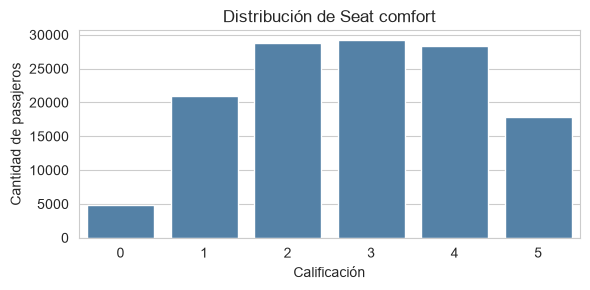

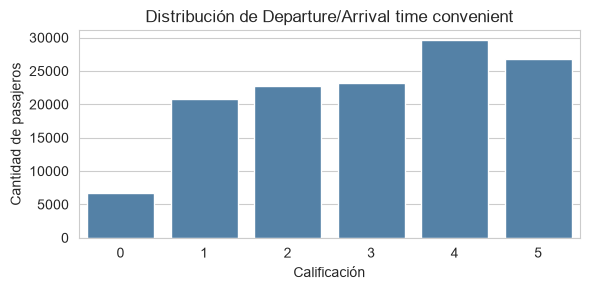

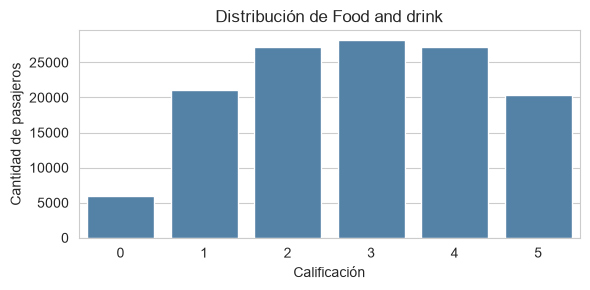

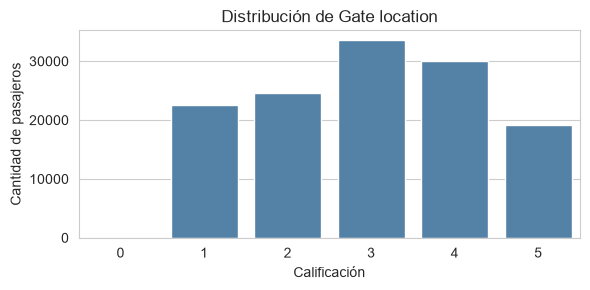

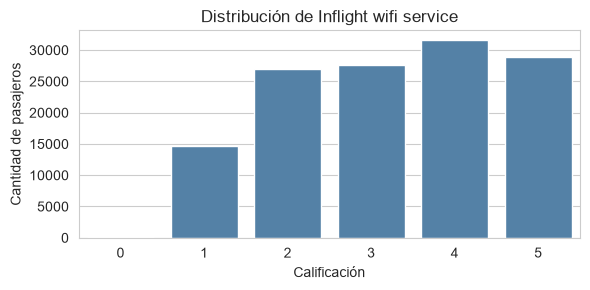

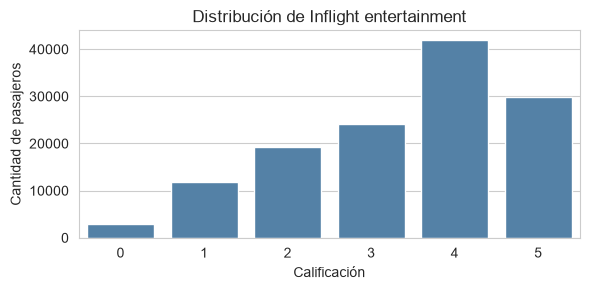

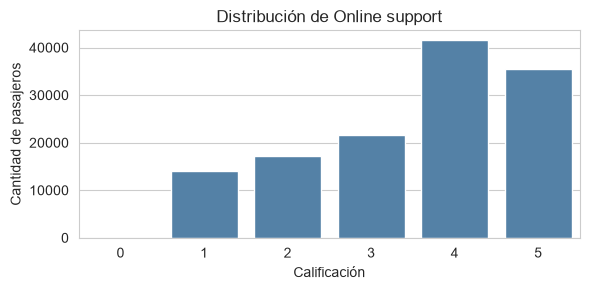

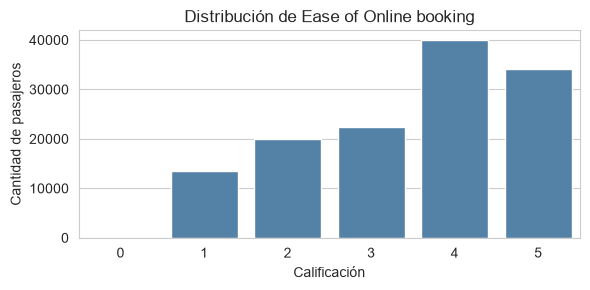

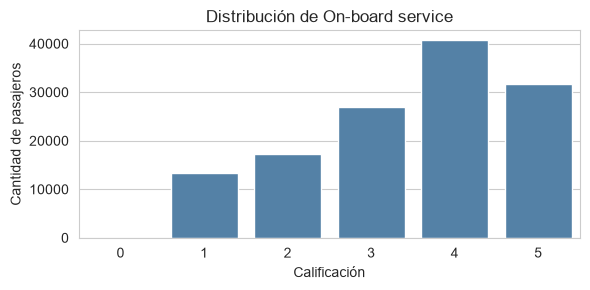

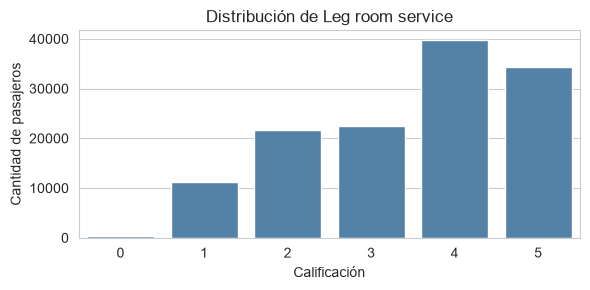

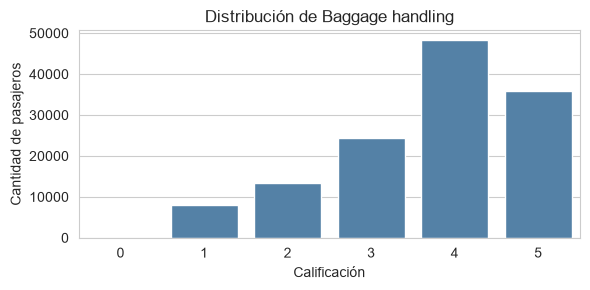

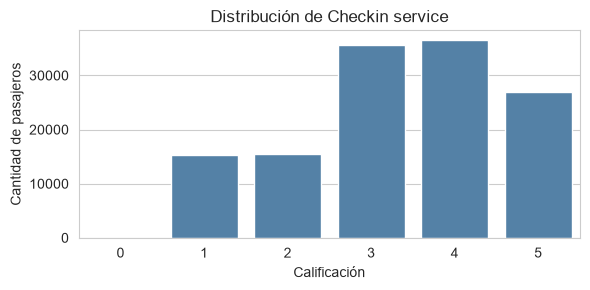

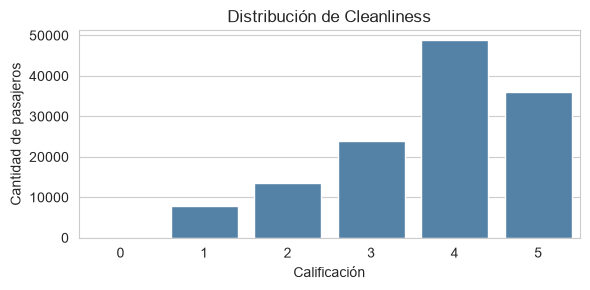

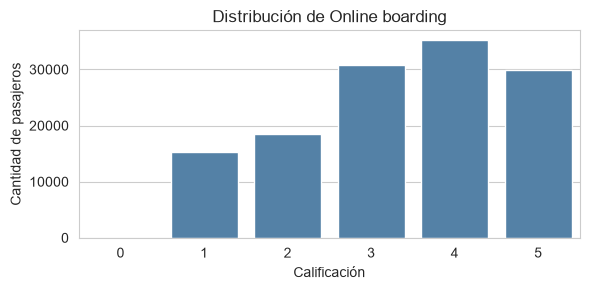

In [7]:
# Calificaciones: frecuencia de cada puntaje de la escala
for col in calificaciones:
    plt.figure(figsize=(6, 3))
    sns.countplot(data=df, x=col, order=range(6), color="steelblue")
    plt.title(f"Distribución de {col}")
    plt.xlabel("Calificación")
    plt.ylabel("Cantidad de pasajeros")
    plt.tight_layout()
    plt.show()

Gender
        cantidad      %
Gender                 
Female     65899  50.74
Male       63981  49.26 

Customer Type
                   cantidad      %
Customer Type                     
Loyal Customer       106100  81.69
disloyal Customer     23780  18.31 

Type of Travel
                 cantidad      %
Type of Travel                  
Business travel     89693  69.06
Personal Travel     40187  30.94 

Class
          cantidad      %
Class                    
Business     62160  47.86
Eco          58309  44.89
Eco Plus      9411   7.25 

satisfaction
              cantidad      %
satisfaction                 
satisfied        71087  54.73
dissatisfied     58793  45.27 



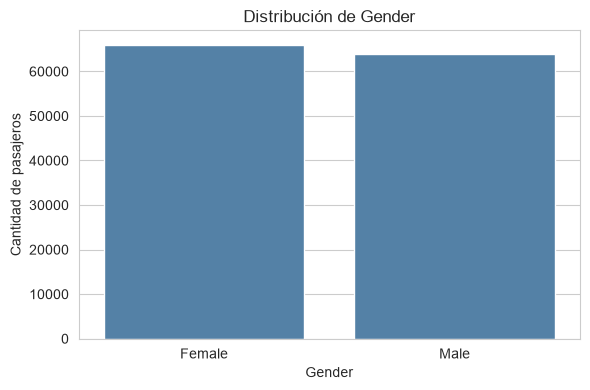

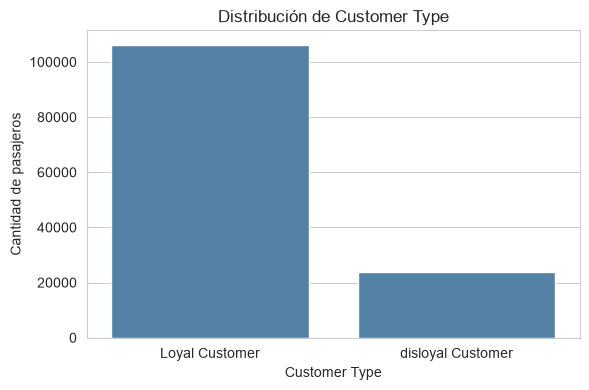

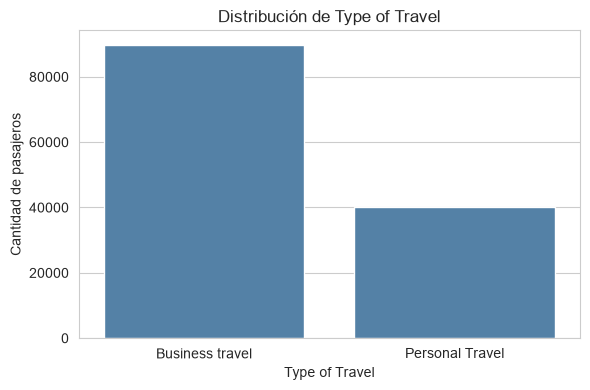

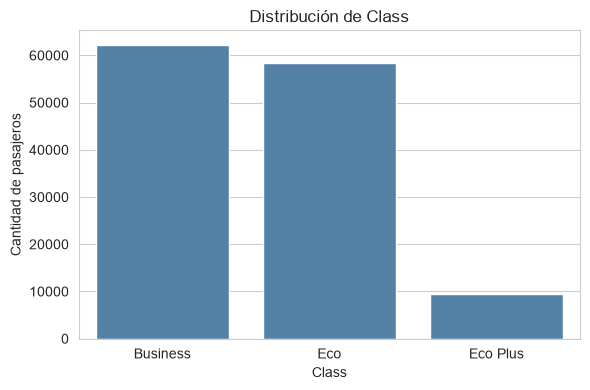

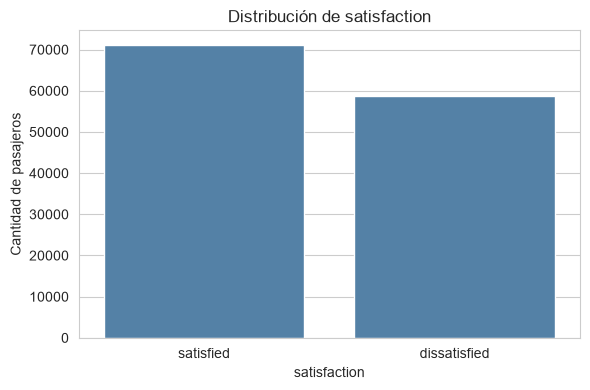

In [8]:
# Variables categóricas y target: frecuencias y porcentajes
for col in categoricas + [target]:
    tabla = pd.DataFrame({
        "cantidad": df[col].value_counts(),
        "%": (df[col].value_counts(normalize=True) * 100).round(2),
    })
    print(col)
    print(tabla, "\n")

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, order=tabla.index, color="steelblue")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Cantidad de pasajeros")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

**Interpretación**

La edad de los pasajeros va de 7 a 85 años, con un promedio de 39,4 y una mediana de 40. La mitad central de los pasajeros tiene entre 27 y 51 años. En `Flight Distance`, la mediana es de 1.925 y el promedio de 1.981,4; el 50% central de las distancias se encuentra entre 1.359 y 2.544, aunque hay vuelos que alcanzan valores de 6.951.

Las demoras de salida y llegada presentan una distribución muy sesgada a la derecha: la mayoría de los registros se concentra en 0 o en retrasos pequeños, mientras que unos pocos tienen demoras muy grandes. En ambas variables la mediana es 0, pero los promedios son de 14,7 y 15,1 minutos, respectivamente. Esto explica por qué en los histogramas se observa una concentración al inicio y una cola larga hacia la derecha, y se relaciona con los outliers que analizamos en el punto 6.

En las calificaciones, el puntaje 4 es el más frecuente en la mayoría de los servicios, por ejemplo `Cleanliness`, `Baggage handling` e `Inflight entertainment`. Sin embargo, `Seat comfort`, `Food and drink` y `Gate location` tienen al 3 como respuesta más frecuente. Por eso conviene observar cada servicio por separado: las respuestas no se distribuyen de la misma forma en todas las preguntas. `Baggage handling` no presenta respuestas con puntaje 0.

En las variables categóricas, `Gender` está bastante equilibrada (50,7% Female y 49,3% Male). En cambio, predominan los clientes leales (81,7%) y los viajes de negocio (69,1%). Las clases Business y Eco representan el 47,9% y el 44,9%, mientras que Eco Plus reúne solo el 7,2% de los pasajeros. Estas diferencias muestran que algunos perfiles tienen mucha más presencia que otros en la muestra.

Finalmente, el target `satisfaction` tiene un 54,7% de pasajeros satisfechos y un 45,3% de insatisfechos. Las dos clases tienen una representación similar, sin un desbalance marcado. Este punto describe la distribución general de cada variable; la relación de esas variables con la satisfacción se analiza en el punto 7.

## 6. Análisis de valores extremos (Outliers)



En este dataset conviene separar dos grupos de variables numéricas antes de buscar outliers:

- **Variables continuas** (`Age`, `Flight Distance`, `Departure Delay in Minutes`, `Arrival Delay in Minutes`): pueden tomar
  cualquier valor dentro de un rango amplio, así que sí tiene sentido buscar valores extremos con boxplots y el método IQR.
- **Variables de calificación / encuesta** (`Seat comfort`, `Inflight wifi service`, `Cleanliness`, etc.): son escalas
  acotadas (normalmente 0-5), por lo que un boxplot puede marcar "outliers" que en realidad son solo la calificación más baja
  o más alta permitida, no un dato erróneo. Por eso las analizamos aparte, más como distribución de frecuencias.


In [9]:
# Variables continuas vs. variables de calificación (escala acotada)
# (se recalculan las numéricas acá para que esta sección funcione sola,
# sin depender de que la sección 5 ya haya sido completada)
num_cols = df.select_dtypes(include="number").columns.tolist()

continuas = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
calificaciones = [c for c in num_cols if c not in continuas]

print("Continuas:", continuas)
print("Calificaciones (escala acotada):", calificaciones)


Continuas: ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
Calificaciones (escala acotada): ['Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding']


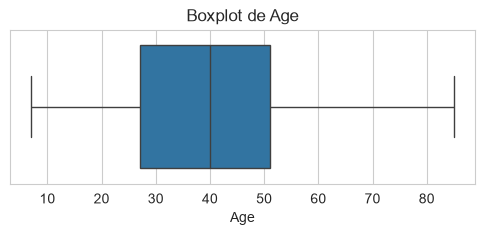

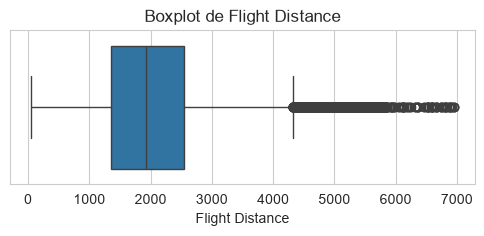

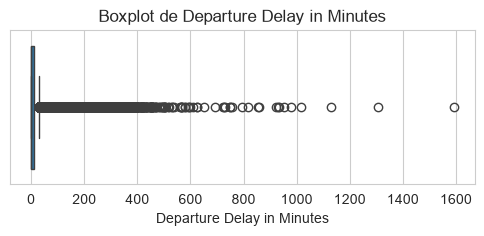

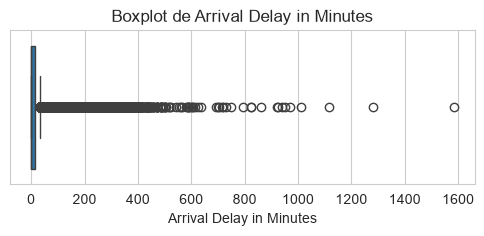

In [10]:
# Boxplots de las variables continuas
for col in continuas:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()


In [11]:
# Detección de outliers por rango intercuartílico (IQR) — solo variables continuas
def contar_outliers_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_outliers = ((serie < lim_inf) | (serie > lim_sup)).sum()
    return n_outliers, lim_inf, lim_sup

resumen_outliers = []
for col in continuas:
    n, lim_inf, lim_sup = contar_outliers_iqr(df[col])
    resumen_outliers.append({
        "variable": col,
        "outliers": n,
        "% outliers": round(100 * n / len(df), 2),
        "límite inferior": round(lim_inf, 2),
        "límite superior": round(lim_sup, 2),
    })

pd.DataFrame(resumen_outliers).sort_values("outliers", ascending=False)


,variable,outliers,% outliers,límite inferior,límite superior
2,Departure Delay in Minutes,18098,13.93,-18.0,30.0
3,Arrival Delay in Minutes,17492,13.47,-19.5,32.5
1,Flight Distance,2581,1.99,-418.5,4321.5
0,Age,0,0.00,-9.0,87.0


In [12]:
# Variables de calificación (escala acotada): no buscamos outliers con IQR,
# sino que revisamos la distribución de las respuestas para ver si hay valores fuera de rango
# (ej. algo distinto de 0-5, que indicaría un error de carga)
df[calificaciones].agg(["min", "max"]).T


,min,max
Seat comfort,0,5
Departure/Arrival time convenient,0,5
Food and drink,0,5
Gate location,0,5
Inflight wifi service,0,5
Inflight entertainment,0,5
Online support,0,5
Ease of Online booking,0,5
On-board service,0,5
Leg room service,0,5


**Interpretación**

Observando los graficos podemos confirmar que las variables con mayor cantidad de outliers son los delays: Departure Delay in Minutes tiene aproximadamente 18.098 valores atípicos (13,9% del dataset) y Arrival Delay in Minutes tiene 17.492 (13,5%), muy por encima de Flight Distance (2.581 outliers, 2%) y Age (0 outliers). Lo cual nos dice que la mayoría de los vuelos sale puntual o con demoras menores, mientras que un grupo más chico de vuelos acumula retrasos muy grandes (el máximo observado en ambas columnas ronda los 1.590 minutos, es decir, más de 26 horas), lo que estira la cola de la distribución y dispara el conteo de outliers con el método IQR.

En este caso, los valores extremos de Departure Delay in Minutes y Arrival Delay in Minutes no parecen errores de carga, sino demoras reales: son consistentes entre sí (los vuelos con mayor atraso en la salida también lo tienen en la llegada) y son justamente los casos más relevantes para el análisis, ya que es esperable que un vuelo muy demorado impacte negativamente en la satisfacción del pasajero (nuestro target). Por eso, decidimos no eliminar estos outliers, sino mantenerlos en el dataset. Para cuando nos toque modelar vamos a evaluar aplicar una transformación logarítmica sobre estas dos variables, ya que su distribución está muy sesgada a la derecha y una transformación puede ayudar a que los modelos capturen mejor la relación con el target sin que unos pocos valores extremos dominen el ajuste.

Luego para la variable de Age, el rango observado es de 7 a 85 años, y para Flight Distance de 50 a 6.951 millas: ambos son valores razonables para un dataset de pasajeros de aerolínea, por lo que no encontramos evidencia de errores de carga en estas dos variables.

En cuanto a las variables de calificación (Seat comfort, Cleanliness, Inflight wifi service, etc.), verificamos que todas están dentro del rango esperado de 0 a 5, salvo Baggage handling, que va de 1 a 5 (no tiene el valor 0). No se detectaron valores fuera de rango que indiquen error de carga.

En conclusión, el único tratamiento de outliers que aplicaremos en esta etapa es sobre los **delays**, y quedará resuelto durante el modelado mediante **transformación logarítmica**, en lugar de eliminar registros.


## 7. Relación de features con el target


El target de este dataset es `satisfaction` (categórico, dos clases: `satisfied` / `dissatisfied`, bastante
balanceadas: ~55% satisfechos y ~45% no satisfechos). Como es un problema de **clasificación**, la relación de
cada feature con el target se analiza distinto según el tipo de variable:

- **Variables continuas** (`Age`, `Flight Distance`, los dos delays): boxplot de la variable separado por clase
  del target, para ver si las distribuciones difieren entre pasajeros satisfechos e insatisfechos.
- **Variables de calificación** (escala 0-5, ej. `Inflight wifi service`, `Cleanliness`): comparamos el promedio
  de cada calificación entre los dos grupos del target — si una calificación es sistemáticamente más alta entre
  los satisfechos, es una señal de que esa variable es importante para el modelo.
- **Variables categóricas** (`Gender`, `Customer Type`, `Type of Travel`, `Class`): comparamos la proporción de
  satisfacción dentro de cada categoría.


In [13]:
target = "satisfaction"

continuas = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
num_cols = df.select_dtypes(include="number").columns.tolist()
calificaciones = [c for c in num_cols if c not in continuas]
categoricas = ["Gender", "Customer Type", "Type of Travel", "Class"]

df[target].value_counts(normalize=True)


satisfaction
satisfied       0.547328
dissatisfied    0.452672
Name: proportion, dtype: float64

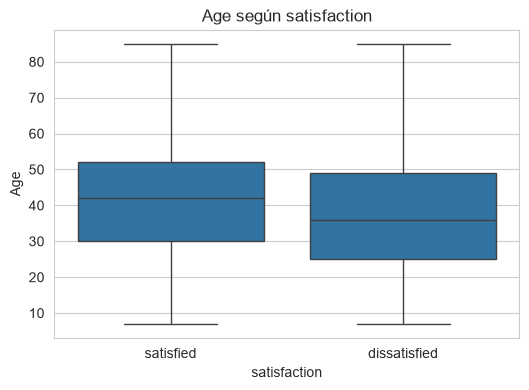

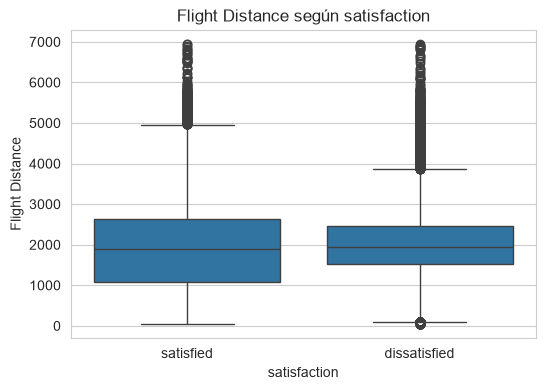

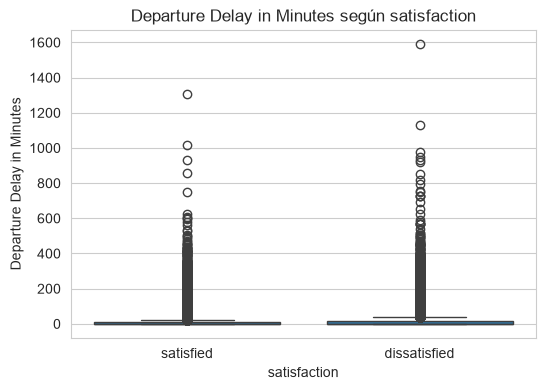

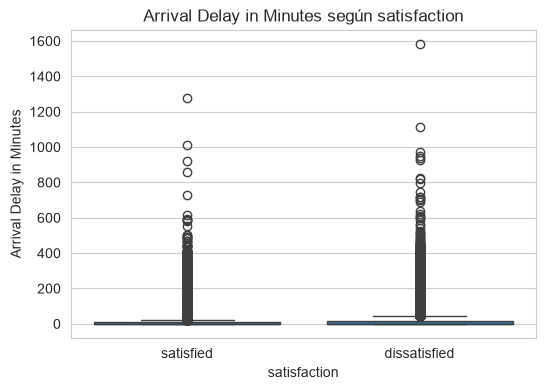

In [14]:
# Variables continuas vs. target: boxplot por clase
for col in continuas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=target, y=col)
    plt.title(f"{col} según {target}")
    plt.show()


In [15]:
# Variables de calificación (0-5) vs. target: promedio por clase
promedio_por_clase = df.groupby(target)[calificaciones].mean().T
promedio_por_clase["diferencia"] = promedio_por_clase["satisfied"] - promedio_por_clase["dissatisfied"]
promedio_por_clase.sort_values("diferencia", ascending=False)


satisfaction,dissatisfied,satisfied,diferencia
Inflight entertainment,2.608644,4.024308,1.415664
Ease of Online booking,2.852261,3.984751,1.132490
Online support,2.959213,3.983260,1.024047
On-board service,2.973126,3.871946,0.898820
Online boarding,2.869695,3.751966,0.882271
Leg room service,3.052625,3.844247,0.791622
Seat comfort,2.467335,3.145653,0.678318
Checkin service,2.971850,3.645955,0.674105
Baggage handling,3.364601,3.969488,0.604887
Inflight wifi service,2.919854,3.521460,0.601605


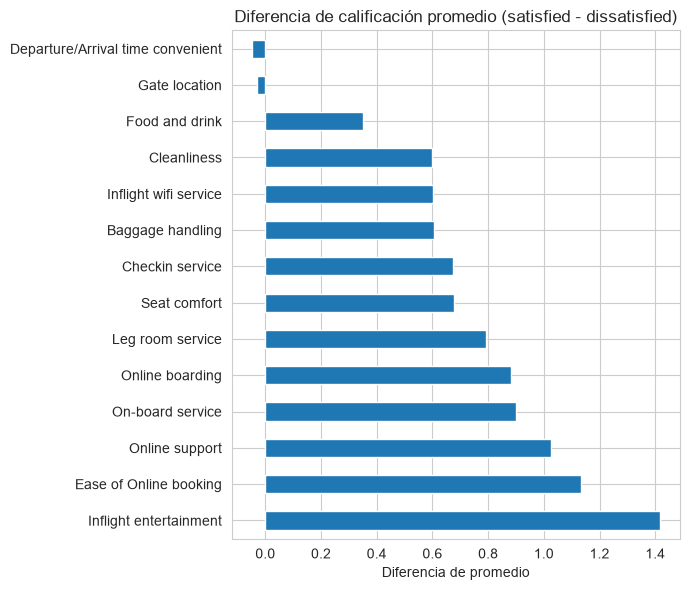

In [16]:
# Visualización de las calificaciones con mayor diferencia entre clases
promedio_por_clase.sort_values("diferencia", ascending=False)["diferencia"].plot(
    kind="barh", figsize=(7, 6), title="Diferencia de calificación promedio (satisfied - dissatisfied)"
)
plt.xlabel("Diferencia de promedio")
plt.tight_layout()
plt.show()


satisfaction  dissatisfied  satisfied
Gender                               
Female            0.348579   0.651421
Male              0.559885   0.440115 



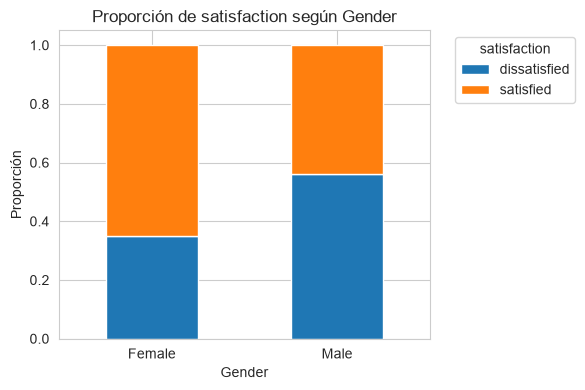

satisfaction       dissatisfied  satisfied
Customer Type                             
Loyal Customer         0.383723   0.616277
disloyal Customer      0.760303   0.239697 



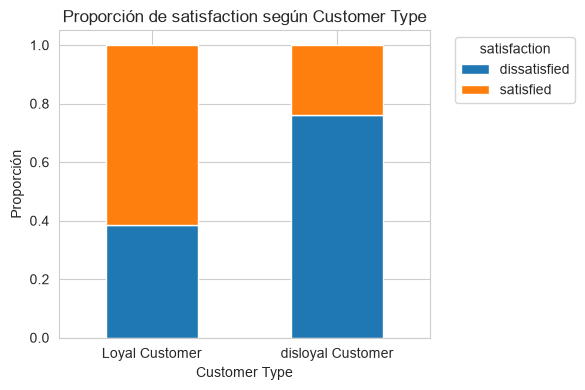

satisfaction     dissatisfied  satisfied
Type of Travel                          
Business travel      0.416276   0.583724
Personal Travel      0.533904   0.466096 



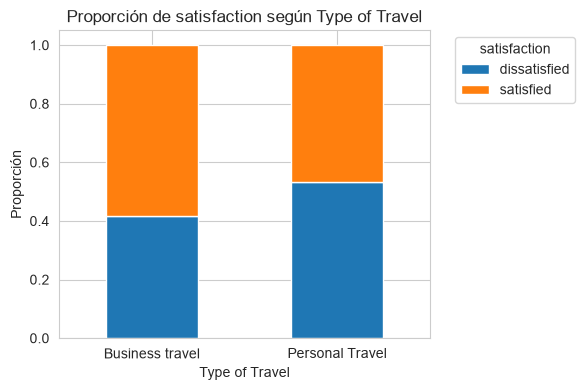

satisfaction  dissatisfied  satisfied
Class                                
Business          0.290621   0.709379
Eco               0.606013   0.393987
Eco Plus          0.572947   0.427053 



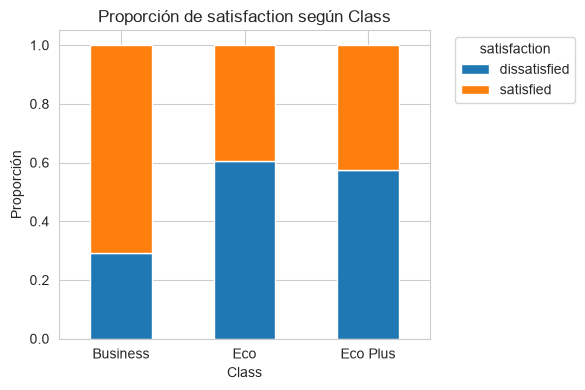

In [17]:
# Variables categóricas vs. target: proporción de satisfacción por categoría
for col in categoricas:
    tabla = pd.crosstab(df[col], df[target], normalize="index")
    print(tabla, "\n")

    tabla.plot(kind="bar", stacked=True, figsize=(6, 4), title=f"Proporción de {target} según {col}")
    plt.ylabel("Proporción")
    plt.xticks(rotation=0)
    plt.legend(title=target, bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()


**Interpretación:**

Podemos observar que los delays sí muestran diferencia entre los dos grupos, pero es una diferencia moderada y no una separación clara: el promedio de Departure Delay in Minutes es de 17,8 minutos entre los insatisfechos contra 12,2 entre los satisfechos, y algo muy similar pasa con Arrival Delay in Minutes (18,5 vs. 12,3 minutos). Sin embargo, la mediana en ambos grupos es 0 en las dos variables, lo que confirma lo que vimos en la sección de outliers: la mayoría de los pasajeros no tiene demoras, y son los pocos casos con demoras muy grandes los que empujan el promedio hacia arriba, especialmente entre los insatisfechos. Esto sugiere que el delay influye, pero probablemente más como un factor que empeora la experiencia en un subgrupo de pasajeros, que como una variable que separe con claridad a toda la población.

Ahora, con Age sí parece tener alguna relación con la satisfacción: los pasajeros satisfechos tienen en promedio 41 años (mediana 42) contra 37,5 años (mediana 36) entre los insatisfechos, es decir, los pasajeros más jóvenes tienden a estar algo menos satisfechos. 

Con Flight Distance, en cambio, no muestra una diferencia relevante entre clases (1.945 km promedio entre satisfechos vs. 2.026 km entre insatisfechos), por lo que no parece ser una variable con mucho poder predictivo por sí sola.

De las variables de calificación, las que muestran mayor diferencia de promedio entre clases son Inflight entertainment (+1,42 puntos a favor de los satisfechos), Ease of Online booking (+1,13), Online support (+1,02) y On-board service (+0,90). Estas son, en principio, las candidatas más fuertes a ser features importantes para el modelo.

En el otro extremo, Gate location y Departure/Arrival time convenient prácticamente no muestran diferencia entre clases (incluso la diferencia es levemente negativa, -0,03 y -0,05), lo que indica que estas dos variables aportan poca información para distinguir entre pasajeros satisfechos e insatisfechos.

En cuanto a las variables categóricas, las tres muestran relación con la satisfacción, pero Customer Type y Class se destacan por la magnitud de la diferencia: los clientes leales están satisfechos en el 61,6% de los casos, contra solo 24% entre los clientes no leales; y en Class, el 70,9% de los pasajeros de Business está satisfecho, contra 39,4% en Eco y 42,7% en Eco Plus. Type of Travel también influye (58,4% de satisfacción en viajes de negocio vs. 46,6% en viajes personales), aunque con una brecha algo menor que las otras dos.

Como conclusión, las variables que elegiríamos como más relevantes para el modelado son: **Inflight entertainment, Ease of Online booking, Online support, Customer Type y Class** ya que son las que muestran mayor diferencia entre pasajeros satisfechos e insatisfechos tanto en las calificaciones como en las variables categóricas.


## 8. Correlación entre variables 

## 9. Conclusiones generales del EDA
